In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv('data/raw/atp_tennis.csv')
df.head()

,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Score
0,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Arthurs W.,Gambill J.M.,Gambill J.M.,105,58,-1,-1,-1.0,-1.0,6-3 6-7 4-6
1,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Balcells J.,Henman T.,Henman T.,218,11,-1,-1,-1.0,-1.0,4-6 6-7
2,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Clement A.,Enqvist T.,Enqvist T.,56,5,-1,-1,-1.0,-1.0,3-6 3-6
3,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Dosedel S.,Ljubicic I.,Dosedel S.,63,77,-1,-1,-1.0,-1.0,6-4 6-2
4,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Draper S.,Norman M.,Norman M.,155,15,-1,-1,-1.0,-1.0,4-6 4-6


In [3]:
print(df.shape)
df.info()

(68300, 17)
<class 'pandas.DataFrame'>
RangeIndex: 68300 entries, 0 to 68299
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tournament  68300 non-null  str    
 1   Date        68300 non-null  str    
 2   Series      68300 non-null  str    
 3   Court       68300 non-null  str    
 4   Surface     68300 non-null  str    
 5   Round       68300 non-null  str    
 6   Best of     68300 non-null  int64  
 7   Player_1    68300 non-null  str    
 8   Player_2    68300 non-null  str    
 9   Winner      68300 non-null  str    
 10  Rank_1      68300 non-null  int64  
 11  Rank_2      68300 non-null  int64  
 12  Pts_1       68300 non-null  int64  
 13  Pts_2       68300 non-null  int64  
 14  Odd_1       68300 non-null  float64
 15  Odd_2       68300 non-null  float64
 16  Score       68300 non-null  str    
dtypes: float64(2), int64(5), str(10)
memory usage: 8.9 MB


In [4]:
print(df.isnull().sum())
print("\nPts_1 == -1:", (df['Pts_1'] == -1).sum())
print("Pts_2 == -1:", (df['Pts_2'] == -1).sum())
print("Odd_1 == -1:", (df['Odd_1'] == -1).sum())
print("Odd_2 == -1:", (df['Odd_2'] == -1).sum())

Tournament    0
Date          0
Series        0
Court         0
Surface       0
Round         0
Best of       0
Player_1      0
Player_2      0
Winner        0
Rank_1        0
Rank_2        0
Pts_1         0
Pts_2         0
Odd_1         0
Odd_2         0
Score         0
dtype: int64

Pts_1 == -1: 15652
Pts_2 == -1: 15653
Odd_1 == -1: 3782
Odd_2 == -1: 3780


Note: Missing data uses -1 as a sentinel rather than NaN, since rankings/odds started later than match records. Confirmed via manual value check rather than using .isnull().

In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

Convert date (string) to a date datatype.

In [6]:
print(df.duplicated().sum())
print(df.duplicated(subset=['Date', 'Player_1', 'Player_2', 'Tournament', 'Round']).sum())

0
0


No duplicated values detected.

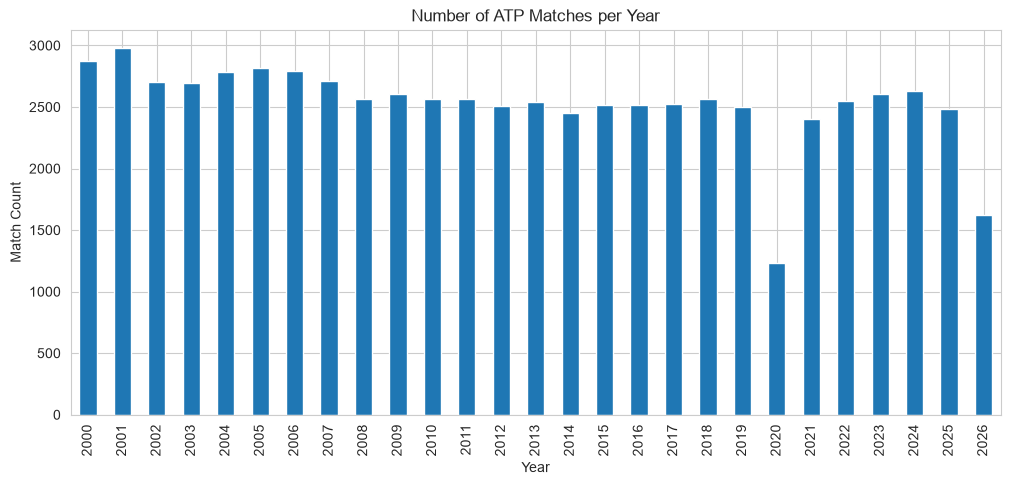

In [7]:
matches_per_year = df.groupby('Year').size()

plt.figure(figsize=(12,5))
matches_per_year.plot(kind='bar')
plt.title('Number of ATP Matches per Year')
plt.xlabel('Year')
plt.ylabel('Match Count')
plt.show()

2020 has significantly fewer matches than other years because of the Covid-19 Pandemic. The average match count per year hovers around 2500.

In [8]:
df[df['Year'] == df['Year'].max()].shape[0]

1620

Current year (2026) is partial, compared to the ~2500 yearly average.

Surface
Hard      36836
Clay      22099
Grass      7733
Carpet     1632
Name: count, dtype: int64


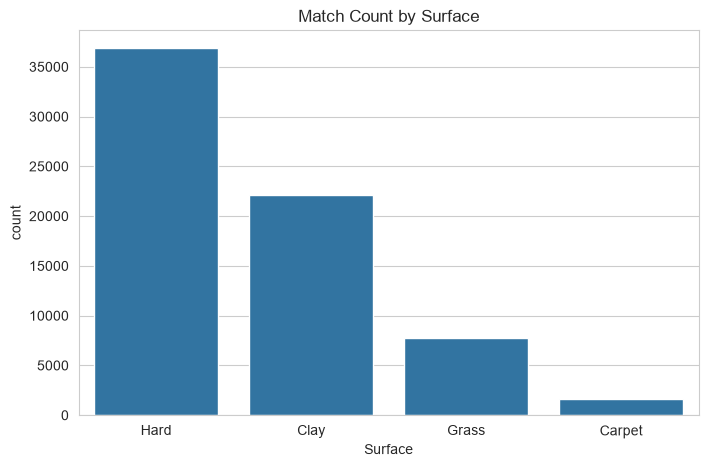

In [9]:
surface_counts = df['Surface'].value_counts()
print(surface_counts)

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Surface', order=surface_counts.index)
plt.title('Match Count by Surface')
plt.show()

Majority of ATP matches are played on Hard Courts. This makes sense, as two Grand Slams are played on Hard Courts (Australian Open & US Open).

In [10]:
df = df[(df['Rank_1'] != -1) & (df['Rank_2'] != -1)]
print(df.shape)

(68274, 18)


Dropped 26 rows with invalid (-1) rank values. Negligible relative to dataset size (68,300 rows).

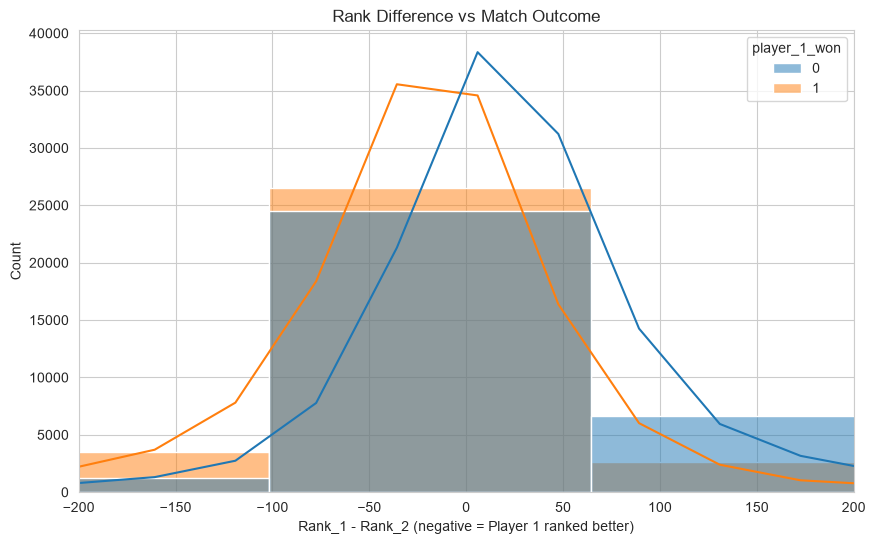

In [11]:
df['rank_diff'] = df['Rank_1'] - df['Rank_2']
df['player_1_won'] = (df['Winner'] == df['Player_1']).astype(int)

plt.figure(figsize=(10,6))
sns.histplot(data=df, x='rank_diff', hue='player_1_won', bins=50, kde=True)
plt.title('Rank Difference vs Match Outcome')
plt.xlabel('Rank_1 - Rank_2 (negative = Player 1 ranked better)')
plt.xlim(-200,200)
plt.show()

In [12]:
df[['rank_diff', 'player_1_won']].corr()

,rank_diff,player_1_won
rank_diff,1.000000,-0.240164
player_1_won,-0.240164,1.000000


This graph tests "do higher-ranked players win more often?". The distributions separate as expected, matches where Player 1 won skew toward negative rank_diff (Player 1 ranked better), confirming the hypothesis.

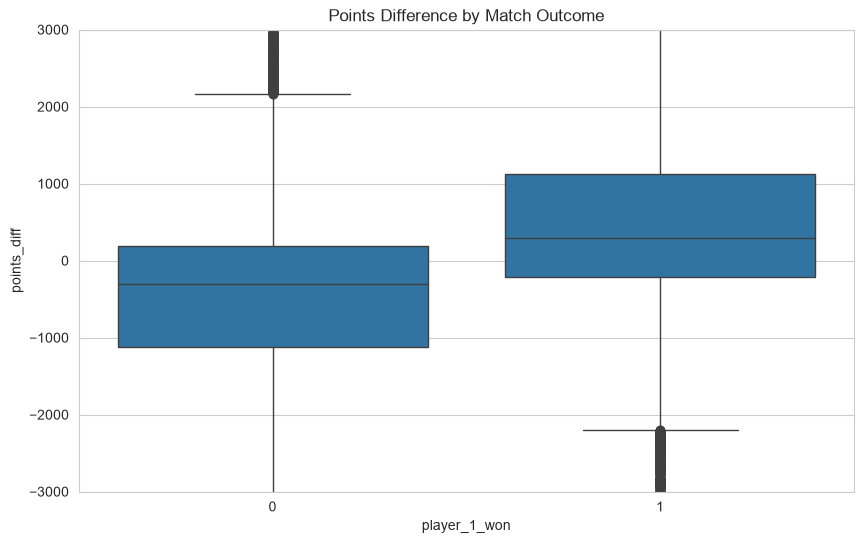

In [13]:
df['points_diff'] = df['Pts_1'] - df['Pts_2']
plt.figure(figsize=(10,6))
mask = (df['Pts_1'] != -1) & (df['Pts_2'] != -1)
sns.boxplot(data=df[mask], x='player_1_won', y='points_diff')
plt.ylim(-3000, 3000)
plt.title('Points Difference by Match Outcome')
plt.show()

In [14]:
df[mask][['points_diff', 'player_1_won']].corr()

,points_diff,player_1_won
points_diff,1.000000,0.322546
player_1_won,0.322546,1.000000


points_diff shows a clear relationship with match outcome, when Player 1 wins, median points_diff is positive (~+300); when player 1 loses, it's negative (~-300). Confirms points_diff as a second strong candidate feature along with rank_diff.

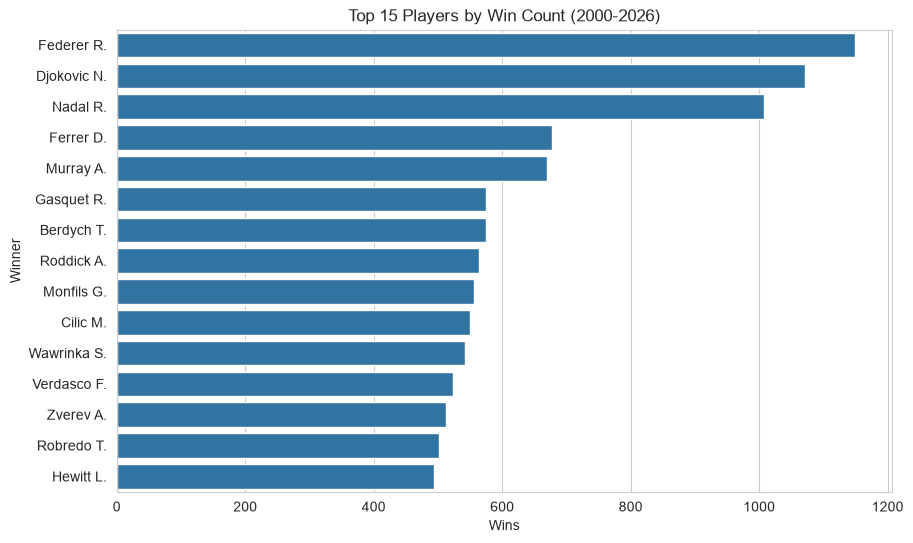

In [15]:
win_counts = df['Winner'].value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=win_counts.values, y=win_counts.index)
plt.title('Top 15 Players by Win Count (2000-2026)')
plt.xlabel('Wins')
plt.show()

The "Big Three" title can be justified for the trio Federer, Djokovic, and Nadal in terms of Win Count, with all three above 1000 wins while the fourth is slightly above 600.

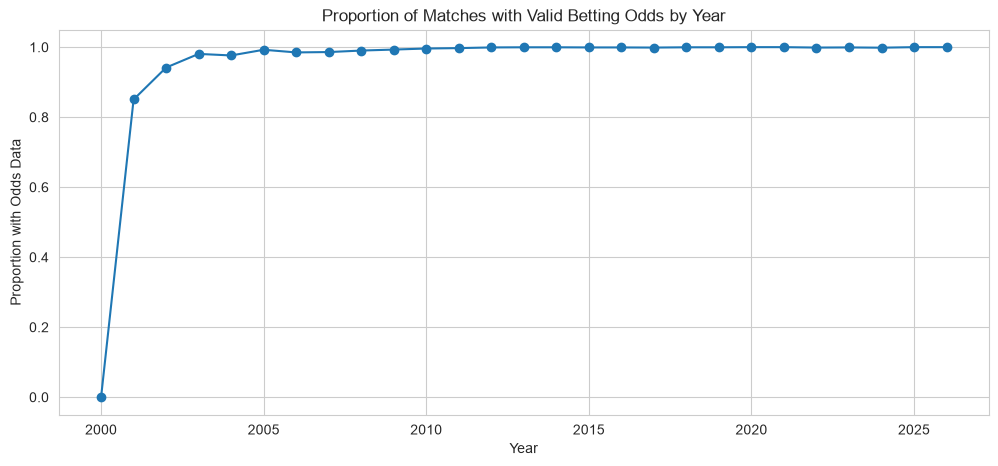

In [16]:
odds_by_year = df.groupby('Year').apply(lambda g: (g['Odd_1'] != -1).mean())

plt.figure(figsize=(12,5))
odds_by_year.plot(kind='line', marker='o')
plt.title('Proportion of Matches with Valid Betting Odds by Year')
plt.ylabel('Proportion with Odds Data')
plt.show()

Odds data populates reliably around 2005.

### EDA Summary: decisions carried into Feature Engineering
The dataset has 68,300 ATP matches from 2000 to 2026, across 17 original columns.

**Missing data isn't what it looks like.** '.isnull()' reports zero missing values everywhere, however, the data uses -1 as a placeholder instead of NaN. Pts_1/Pts_2 are missing in about 15,650 rows each (~23% of the data), and Odd_1/Odd_2 are missing in about 3,700 rows each (~5.5%). Any feature built from these columns needs to explicitly filter out -1 first.

**No real duplicate matches.** Checked a strict full-row duplicate check and subset check on Date + Player_1 + Player_2 + Tournament + Round, and both came back at 0. Two rows initially looked like duplicates on a narrower subset, but turned out to be a round robin match and a final between the same two players.

**Data coverage has two gaps worth remembering.** 2020 has a visible dip in match count, almost certainly Covid-related. 2026 is a partial year (1,620 matches so far vs. a ~2,500/year average), so it shouldn't be treated as a full year in any year-over-year comparison.

**Surface is heavily skewed toward Hard courts** (36,836 matches vs. 22,099 Clay, 7,733 Grass, and just 1,632 Carpet) — makes sense given two of the four Grand Slams are played on hard courts. Worth keeping in mind that the model will have much less to learn from on Grass and Carpet.

**Rank difference and points difference both hold up as real predictive signals.** After dropping 26 rows with invalid rank values (a negligible amount), rank_diff shows a -0.24 correlation with player_1_won, and points_diff shows a 0.32 correlation — both confirm that the better-ranked/higher-points player wins more often, and points_diff appears to be the slightly stronger of the two. Worth noting the two features run in opposite directions: negative rank_diff favors Player 1 (lower rank number is better), while positive points_diff favors Player 1 (more points is better).

**Odds data is only reliable from around 2005 onward.** Any model that wants to use Odd_1/Odd_2 as a feature will need to either filter to 2005+ or treat it as a separate bonus comparison against the stats-only model, rather than using it across the full date range.

**Going into Feature Engineering, this means:**
- Every feature built from Pts or Odd columns needs an explicit -1 filter
- rank_diff and points_diff are both confirmed as core features
- Surface should be encoded, but Grass/Carpet will have less data to learn from
- Any rolling/time-based feature needs to account for 2026 being incomplete
- An odds-inclusive model is a legitimate second model, not the primary one, since odds data doesn't exist for a meaningful chunk of the dataset

In [18]:
df.to_csv('data/processed/atp_matches_clean.csv', index=False)